In [1]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print("Step 3.1 — Checking Missing Values")
print(df.isnull().sum())


Step 3.1 — Checking Missing Values
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [3]:
print("\nStep 3.2 — Handling Missing Values")
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Not Rated")
df['duration'] = df['duration'].fillna("Unknown")
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df.dropna(subset=['title', 'type'], inplace=True)
df.reset_index(drop=True, inplace=True)



Step 3.2 — Handling Missing Values


In [4]:
print("\nStep 3 Completed")
print("Final Shape After Cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Step 3 Completed
Final Shape After Cleaning: (8807, 12)

Missing Values After Cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [5]:

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'] = df['date_added'].fillna(pd.Timestamp("2000-01-01"))
df['date_added'] = df['date_added'].dt.date

In [6]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [7]:
print("\nStep 3.2 — Removing Duplicate Rows")
before_duplicates = df.shape[0]
df.drop_duplicates(inplace=True)
after_duplicates = df.shape[0]
print("Duplicates Removed:", before_duplicates - after_duplicates)


Step 3.2 — Removing Duplicate Rows
Duplicates Removed: 0


In [8]:

df['listed_in'] = df['listed_in'].str.lower()
df['rating'] = df['rating'].str.lower()
df['country'] = df['country'].str.lower()


In [9]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...


In [10]:
genre_dummies = df['listed_in'].str.get_dummies(sep=', ')
df = pd.concat([df, genre_dummies], axis=1)


In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,teen tv shows,thrillers,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,...,0,0,0,0,0,0,0,0,0,0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,0,1,0,1,0,0,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,1,0,0,0,0,0,0,0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,0,0,0,0,0,0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,1,0,0,0,0,0,0


In [12]:
df['rating_encoded'] = df['rating'].astype('category').cat.codes


In [13]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,thrillers,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,...,0,0,0,0,0,0,0,0,0,8
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,1,0,1,0,0,0,12
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,...,0,1,0,0,0,0,0,0,0,12
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,0,0,0,0,0,12
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,1,0,0,0,0,0,0,12


In [14]:
df['country_encoded'] = df['country'].astype('category').cat.codes


In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,...,0,0,0,0,0,0,0,0,8,603
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,1,0,1,0,0,0,12,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,...,1,0,0,0,0,0,0,0,12,736
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,0,0,0,0,12,736
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,...,0,1,0,0,0,0,0,0,12,251


In [16]:
print(df.head())
print("Final Shape:", df.shape)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                      Not Available  united states   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   south africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        unknown   
3                                      Not Available        unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          india   

   date_added  release_year rating   duration  ... tv action & adventure  \
0  2021-09-25          2020  pg-13     90 min  ...                     0   
1  2021-09-24          2021  tv-ma  2 Seasons  .

In [17]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,...,0,0,0,0,0,0,0,0,8,603
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,1,0,1,0,0,0,12,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,...,1,0,0,0,0,0,0,0,12,736
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,0,0,0,0,12,736
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,...,0,1,0,0,0,0,0,0,12,251


Analyze Netflix Content Growth Over Time

In [18]:
df.to_csv("cleaned_dataset.csv", index=False)


In [19]:
print("Final Shape:", df.shape)
df.to_csv("cleaned_dataset.csv", index=False)


Final Shape: (8807, 56)


1.Analyze Netflix Content Growth Over Time

Extract Year from date_added

In [20]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [21]:
df['year_added'] = df['date_added'].dt.year

Count content added each year

In [22]:
content_growth = df['year_added'].value_counts().sort_index()

print(content_growth)

year_added
2000      98
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: int64


Visualize Growth

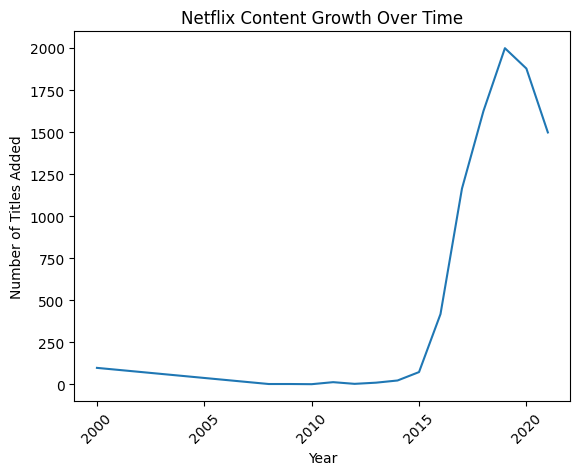

In [23]:
import matplotlib.pyplot as plt

plt.figure()
content_growth.plot(kind='line')
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.show()

2.Distribution of Genres, Ratings & Content Type

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


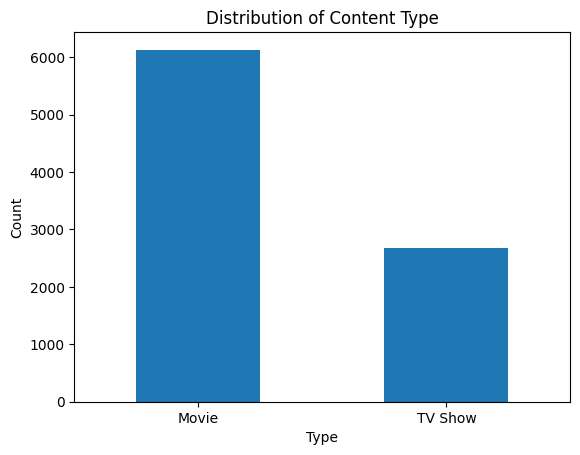

In [24]:
type_distribution = df['type'].value_counts()

print(type_distribution)

plt.figure()
type_distribution.plot(kind='bar')
plt.title("Distribution of Content Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Distribution of Ratings

rating
tv-ma        3207
tv-14        2160
tv-pg         863
r             799
pg-13         490
tv-y7         334
tv-y          307
pg            287
tv-g          220
nr             80
g              41
tv-y7-fv        6
not rated       4
nc-17           3
ur              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64


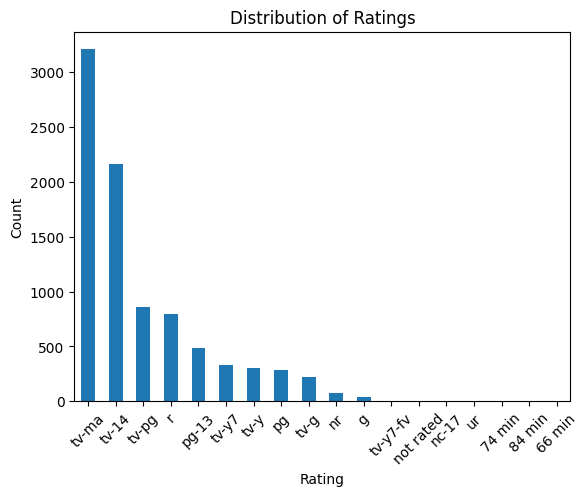

In [25]:
rating_distribution = df['rating'].value_counts()

print(rating_distribution)

plt.figure()
rating_distribution.plot(kind='bar')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Genre Distribution

In [26]:
# Split multiple genres
df['listed_in'] = df['listed_in'].str.split(',')

# Explode genres into separate rows
genre_df = df.explode('listed_in')

# Remove extra spaces
genre_df['listed_in'] = genre_df['listed_in'].str.strip()

Count genres

listed_in
international movies        2752
dramas                      2427
comedies                    1674
international tv shows      1351
documentaries                869
action & adventure           859
tv dramas                    763
independent movies           756
children & family movies     641
romantic movies              616
Name: count, dtype: int64


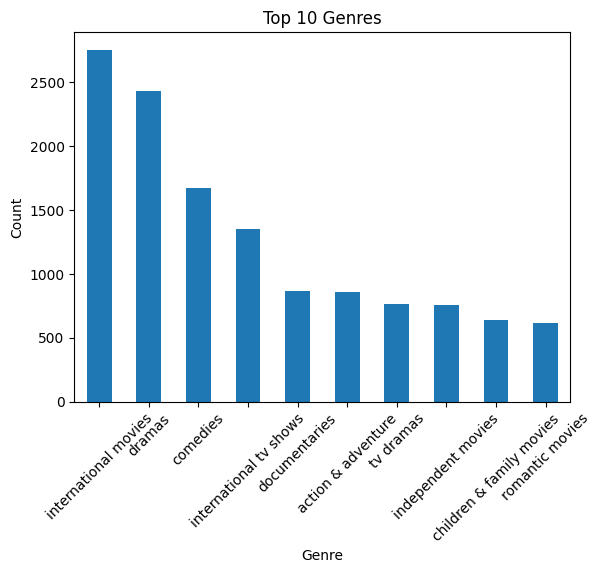

In [27]:
genre_distribution = genre_df['listed_in'].value_counts().head(10)

print(genre_distribution)

plt.figure()
genre_distribution.plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

3.Country-Level Content Contributions

Handle multiple countries

In [28]:
df['country'] = df['country'].str.split(',')

country_df = df.explode('country')
country_df['country'] = country_df['country'].str.strip()

Count by country

country
united states     3690
india             1046
unknown            831
united kingdom     806
canada             445
france             393
japan              318
spain              232
south korea        231
germany            226
Name: count, dtype: int64


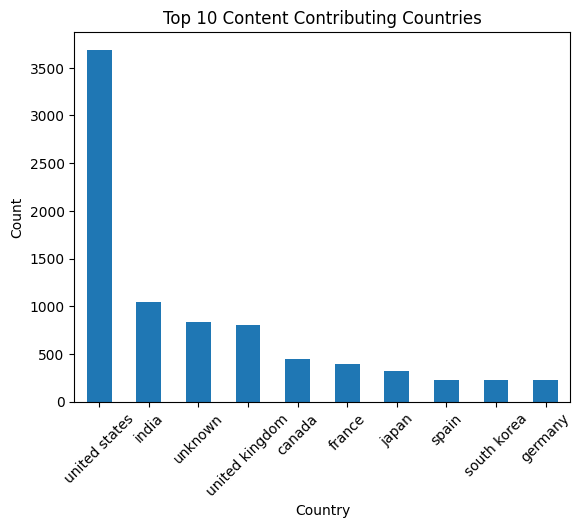

In [29]:
country_distribution = country_df['country'].value_counts().head(10)

print(country_distribution)

plt.figure()
country_distribution.plot(kind='bar')
plt.title("Top 10 Content Contributing Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

4.Feature Engineering

Content Length Category

In [30]:
df['duration_number'] = df['duration'].str.extract(r'(\d+)')
df['duration_number'] = df['duration_number'].astype(float)

Create Content Length Category (Only for Movies)

In [31]:
def length_category(row):
    if row['type'] == 'Movie':
        if row['duration_number'] < 60:
            return 'Short'
        elif row['duration_number'] <= 120:
            return 'Medium'
        else:
            return 'Long'
    else:
        return 'TV Show'

df['content_length_category'] = df.apply(length_category, axis=1)

print(df['content_length_category'].value_counts())

content_length_category
Medium     4528
TV Show    2676
Long       1145
Short       458
Name: count, dtype: int64


Original vs Licensed

In [32]:
df['original_vs_licensed'] = df['title'].apply(
    lambda x: 'Original' if 'Netflix' in x else 'Licensed'
)

print(df['original_vs_licensed'].value_counts())

original_vs_licensed
Licensed    8803
Original       4
Name: count, dtype: int64


In [33]:
print("Final Shape After EDA & Feature Engineering:", df.shape)
print("\nNew Columns Added:")
print(['year_added', 'duration_number', 
       'content_length_category', 'original_vs_licensed'])

Final Shape After EDA & Feature Engineering: (8807, 60)

New Columns Added:
['year_added', 'duration_number', 'content_length_category', 'original_vs_licensed']


In [34]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded,year_added,duration_number,content_length_category,original_vs_licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,[united states],2021-09-25,2020,pg-13,90 min,...,0,0,0,0,8,603,2021,90.0,Medium,Licensed
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[south africa],2021-09-24,2021,tv-ma,2 Seasons,...,1,0,0,0,12,426,2021,2.0,TV Show,Licensed
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[unknown],2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,12,736,2021,1.0,TV Show,Licensed
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,[unknown],2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,12,736,2021,1.0,TV Show,Licensed
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",[india],2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,0,12,251,2021,2.0,TV Show,Licensed


In [35]:
df.to_csv("netflix_milestone2_final_dataset.csv", index=False)
